In [2]:
import gdown

url = "https://drive.google.com/uc?id=1281E0CDneuKdflWFBUvuyUzujpdGVImz"
gdown.download(url, 'nlp_model.pkl', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1281E0CDneuKdflWFBUvuyUzujpdGVImz
To: /content/nlp_model.pkl
100%|██████████| 309k/309k [00:00<00:00, 13.1MB/s]


'nlp_model.pkl'

In [3]:
import pickle
with open('nlp_model.pkl', 'rb') as f:
    word_embeddings = pickle.load(f)


In [5]:
from sklearn.decomposition import PCA
import numpy as np

words = list(word_embeddings.keys())
vectors = np.array([word_embeddings[w] for w in words])

print(vectors.shape)

(243, 300)


стиснемо до 3ох вимірів


In [11]:
pca = PCA(n_components=3)
vectors_3d = pca.fit_transform(vectors)

print(vectors_3d.shape)
print(vectors_3d[0])
print(words[0])

(243, 3)
[ 0.74603677 -0.3879644  -0.48269066]
country


In [12]:
import pandas as pd

df_words = pd.DataFrame({
    'word': words,
    'x': vectors_3d[:, 0],
    'y': vectors_3d[:, 1],
    'z': vectors_3d[:, 2]
})

df_words.head()

,word,x,y,z
0,country,0.746037,-0.387964,-0.482691
1,city,0.102492,0.140384,-1.189891
2,China,0.831055,-0.129500,-0.312599
3,Iraq,0.656337,-0.177791,-0.338381
4,oil,0.658345,-0.432464,-0.621213


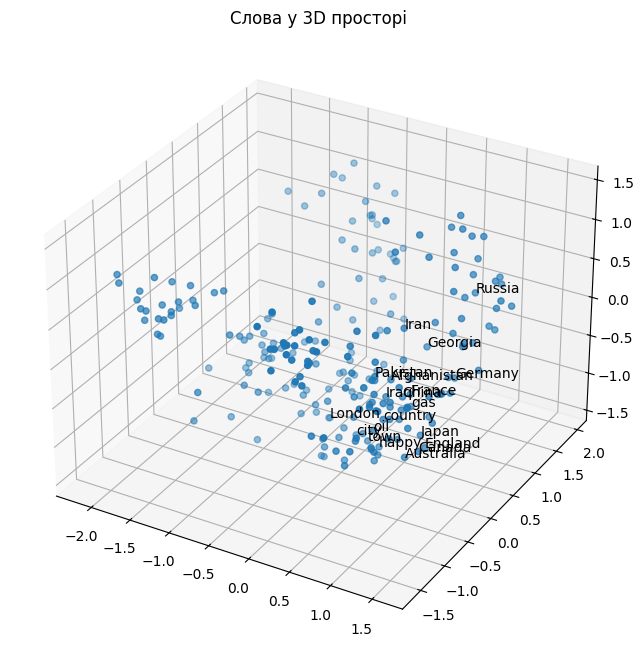

In [23]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_words['x'], df_words['y'], df_words['z'])

for _, row in df_words.head(20).iterrows():
    ax.text(row['x'], row['y'], row['z'], row['word'])

plt.title('Слова у 3D просторі')
plt.show()

In [24]:
def find_nearest_word(vector, df, exclude_word=None):
    distances = np.sqrt(
        (df['x'] - vector[0])**2 +
        (df['y'] - vector[1])**2 +
        (df['z'] - vector[2])**2
    )
    if exclude_word:
        mask = df['word'] != exclude_word
        distances = distances[mask]
    nearest_idx = distances.idxmin()
    return df.loc[nearest_idx, 'word']

тест


In [25]:
test_vector = df_words[df_words['word'] == 'country'][['x', 'y', 'z']].values[0]
result = find_nearest_word(test_vector, df_words, exclude_word='country')
print(result)

Thailand


In [26]:
vec_country = df_words[df_words['word'] == 'country'][['x', 'y', 'z']].values[0]
vec_city = df_words[df_words['word'] == 'city'][['x', 'y', 'z']].values[0]

cross_product = np.cross(vec_country, vec_city)
print("Вектор:", cross_product)

nearest_word = find_nearest_word(cross_product, df_words, exclude_word=None)
print("Найближче слово:", nearest_word)

Вектор: [0.5293972  0.8382302  0.14449482]
Найближче слово: Georgia


In [32]:
def angle_between_words(word1, word2, df):
    vec1 = df[df['word'] == word1][['x', 'y', 'z']].values[0]
    vec2 = df[df['word'] == word2][['x', 'y', 'z']].values[0]

    cos_theta = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # захист від float помилки!

    angle = np.degrees(np.arccos(cos_theta))
    return angle
angle = angle_between_words('country', 'city', df_words)
print(f"Кут між 'country' і 'city': {angle:.2f}°")

Кут між 'country' і 'city': 59.24°


тест


In [33]:
# Схожі слова
print(angle_between_words('China', 'Iraq', df_words))

# Різні слова
print(angle_between_words('oil', 'city', df_words))

# Дуже різні
print(angle_between_words('country', 'oil', df_words))

8.377448
51.8039
9.6858015


 Висновки

1. PCA стиснув вектори з 300 → 3 виміри,
   зберігши ~25% інформації.

2. Слова які часто згадуються разом у новинах
   мають малий кут між векторами:
   - China і Iraq: 8.4°
   - country і oil: 9.7°

3. Векторний добуток country × city → Georgia
   (географічна концепція, пов'язана з обома словами)

4. Великий кут означає відсутність зв'язку між словами,
   а не протилежність (антонімічність)